<a href="https://colab.research.google.com/github/A-Vineela/HAR-Project/blob/main/03_Improved_Robust_Multiclass_Action_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Improved Robust Multiclass Human Action Detection

**Goal :** build a multiclass action detection model, with a *primary* focus on
detailed performance analysis in the wild and on out-of-distribution (OOD) / failure cases — and,
as a secondary goal, try to close that gap using stronger approaches:

1. Transfer learning + a much better training recipe (this notebook)
2. A multi-step (hierarchical) classification approach
3. An incremental-training utility for adding new data later

This notebook picks up where `01_EDA.ipynb` left off. The baseline scratch CNN from that notebook
only reached **43.85% best validation accuracy**, and Grad-CAM showed it was leaning on background/
context rather than the action itself for several classes (e.g. everything with a laptop-shaped
object nearby getting predicted as `using_laptop`). Everything below is built to fix that, and then
to *measure* robustness explicitly rather than assume it.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Re-download the dataset (skip if already extracted from 01_EDA.ipynb in this runtime)
import os

if not os.path.exists("/content/HAR_dataset"):
    os.system(
        'wget -q -O /content/HAR_dataset.zip '
        '"https://www.kaggle.com/api/v1/datasets/download/meetnagadia/human-action-recognition-har-dataset"'
    )
    import zipfile
    with zipfile.ZipFile("/content/HAR_dataset.zip", "r") as z:
        z.extractall("/content/HAR_dataset")

print("Dataset ready:", os.path.exists("/content/HAR_dataset"))

Dataset ready: True


In [3]:
import pandas as pd

DATA_PATH = "/content/HAR_dataset/Human Action Recognition"
TRAIN_PATH = f"{DATA_PATH}/train"
TEST_PATH  = f"{DATA_PATH}/test"
TRAIN_CSV  = f"{DATA_PATH}/Training_set.csv"

train_df = pd.read_csv(TRAIN_CSV)
print("Training CSV:", train_df.shape)

Training CSV: (12600, 2)


## 1. Re-create the exact same split as the baseline

Same duplicate-aware, stratified, `random_state=42` split used in `01_EDA.ipynb`. This is
important: if the split changes, the baseline (40.8% final / 43.85% best) and the new model
aren't comparable anymore.


In [4]:
import hashlib
from collections import defaultdict
from sklearn.model_selection import train_test_split

def get_image_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_files = defaultdict(list)
for filename in train_df["filename"]:
    path = os.path.join(TRAIN_PATH, filename)
    hash_to_files[get_image_hash(path)].append(filename)

duplicate_groups = {h: files for h, files in hash_to_files.items() if len(files) > 1}

file_to_group = {}
for group_id, files in enumerate(duplicate_groups.values()):
    for f in files:
        file_to_group[f] = group_id

next_group_id = len(duplicate_groups)
for filename in train_df["filename"]:
    if filename not in file_to_group:
        file_to_group[filename] = next_group_id
        next_group_id += 1

train_df["group_id"] = train_df["filename"].map(file_to_group)

groups = train_df.groupby("group_id").agg(label=("label", "first")).reset_index()

train_groups, val_groups = train_test_split(
    groups, test_size=0.20, stratify=groups["label"], random_state=42
)

train_group_ids = set(train_groups["group_id"])
val_group_ids = set(val_groups["group_id"])

train_split = train_df[train_df["group_id"].isin(train_group_ids)].copy()
val_split = train_df[train_df["group_id"].isin(val_group_ids)].copy()

print("Training samples:", len(train_split))
print("Validation samples:", len(val_split))
assert len(set(train_split["group_id"]) & set(val_split["group_id"])) == 0, "Leakage detected!"


Training samples: 10078
Validation samples: 2522


## 2. Data pipeline v2

Two changes from the baseline pipeline:

- **Aspect-ratio-preserving resize + padding** is used everywhere (this was flagged in the EDA as
  the safer choice — direct resize distorts poses).
- **Stronger, wider augmentation**: `TrivialAugmentWide` (search-free RandAugment variant) +
  `RandomErasing` (simulates occlusion) + `MixUp`/`CutMix` at the batch level. The baseline only
  used flip/rotation/color-jitter, which is weak relative to how little data we have per class
  (840 images/class) and is a big reason the scratch CNN overfit to background shortcuts.


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

class ResizeWithPadding:
    """ Aspect-ratio preserving resize onto a square canvas (from 01_EDA.ipynb). """
    def __init__(self, size):
        self.size = size

    def __call__(self, image):
        width, height = image.size
        scale = self.size / max(width, height)
        new_width, new_height = int(round(width * scale)), int(round(height * scale))
        image = image.resize((new_width, new_height), Image.Resampling.BILINEAR)
        canvas = Image.new("RGB", (self.size, self.size))
        left = (self.size - new_width) // 2
        top = (self.size - new_height) // 2
        canvas.paste(image, (left, top))
        return canvas


train_transform = transforms.Compose([
    ResizeWithPadding(IMG_SIZE),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),  # simulates partial occlusion
])

val_transform = transforms.Compose([
    ResizeWithPadding(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [6]:
classes = sorted(train_df["label"].unique())
class_to_idx = {label: idx for idx, label in enumerate(classes)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}
NUM_CLASSES = len(classes)
print(NUM_CLASSES, "classes:", classes)

15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']


In [7]:
class HARDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row["filename"])).convert("RGB")
        label = class_to_idx[row["label"]]
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = HARDataset(train_split, TRAIN_PATH, transform=train_transform)
val_dataset   = HARDataset(val_split,   TRAIN_PATH, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 314 | Val batches: 79


In [8]:
def mixup_cutmix(images, labels, num_classes, alpha=0.2, cutmix_prob=0.5):
    """ Randomly applies MixUp or CutMix to a batch. Returns soft targets. """
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size, device=images.device)

    y_onehot = F.one_hot(labels, num_classes).float()
    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[index]

    if np.random.rand() < cutmix_prob:
        H, W = images.shape[-2:]
        cut_rat = np.sqrt(1.0 - lam)
        cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
        cx, cy = np.random.randint(W), np.random.randint(H)
        x1, x2 = np.clip(cx - cut_w // 2, 0, W), np.clip(cx + cut_w // 2, 0, W)
        y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
        images[:, :, y1:y2, x1:x2] = images[index][:, :, y1:y2, x1:x2]
        lam_adj = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
        y_mixed = lam_adj * y_onehot + (1 - lam_adj) * y_onehot[index]
    else:
        images = lam * images + (1 - lam) * images[index]

    return images, y_mixed

## 3. Model: transfer learning instead of a scratch CNN

The baseline was a 4-block CNN trained from scratch on ~10k images — that's simply not enough
data to learn robust, generalizable features for 15 fine-grained human actions. Swapping to an
ImageNet-pretrained backbone (`EfficientNet-V2-S`) gives the model features that already encode
pose, texture, and object shape, so the classifier head only has to learn how to *combine* them
for these 15 classes.

Training strategy: **two phases**.
- Phase 1 — freeze the backbone, train only the new classifier head (fast, stabilizes the head
  before touching pretrained weights).
- Phase 2 — unfreeze the whole network and fine-tune end-to-end with a much smaller learning
  rate on the backbone than on the head (discriminative learning rates).


In [9]:
import torchvision
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

def build_model(num_classes=NUM_CLASSES, dropout=0.3):
    weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
    backbone = efficientnet_v2_s(weights=weights)
    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return backbone

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device)
print("Device:", device)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 179MB/s]


Device: cuda
Trainable params: 20196703


In [10]:
def set_backbone_trainable(model, trainable: bool):
    for name, param in model.named_parameters():
        if not name.startswith("classifier"):
            param.requires_grad = trainable

# Phase 1: freeze backbone
set_backbone_trainable(model, trainable=False)
print("Frozen. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Frozen. Trainable params: 19215


## 4. Training recipe

Everything the baseline was missing:

| | Baseline | This notebook |
|---|---|---|
| Backbone | scratch CNN | ImageNet-pretrained EfficientNet-V2-S |
| Loss | plain cross-entropy | label-smoothed CE (+ soft targets from MixUp/CutMix) |
| Optimizer | Adam, flat LR | AdamW, discriminative LR (head ≫ backbone) |
| Schedule | none | cosine decay with linear warmup |
| Regularization | none | weight decay, dropout, RandomErasing, MixUp/CutMix, gradient clipping |
| Precision | fp32 | mixed precision (AMP) |
| Stopping | fixed 20 epochs | early stopping on val accuracy + best-checkpoint restore |
| EMA | none | exponential moving average of weights for eval |


In [11]:
from torch.optim.lr_scheduler import LambdaLR
import math, copy

class EMA:
    """ Exponential moving average of model weights - usually evaluates ~0.5-1pt higher and is
    much more stable on the wild/OOD sets than the raw weights. """
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for ema_p, p in zip(self.shadow.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(p.detach(), alpha=1 - self.decay)
        for ema_b, b in zip(self.shadow.buffers(), model.buffers()):
            ema_b.copy_(b)


def cosine_warmup_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)


def soft_ce_loss(logits, soft_targets, smoothing=0.1):
    n_classes = logits.size(1)
    soft_targets = soft_targets * (1 - smoothing) + smoothing / n_classes
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

In [12]:
def train_one_phase(model, train_loader, val_loader, epochs, head_lr, backbone_lr,
                     use_mixup=True, patience=5, ema_decay=0.999, grad_clip=1.0):
    head_params = [p for n, p in model.named_parameters() if n.startswith("classifier")]
    backbone_params = [p for n, p in model.named_parameters()
                        if not n.startswith("classifier") and p.requires_grad]

    param_groups = [{"params": head_params, "lr": head_lr}]
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": backbone_lr})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    total_steps = epochs * len(train_loader)
    scheduler = cosine_warmup_scheduler(optimizer, warmup_steps=int(0.05 * total_steps),
                                         total_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler()
    ema = EMA(model, decay=ema_decay)

    best_val_acc, best_state, epochs_no_improve = 0.0, None, 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                if use_mixup:
                    mixed_images, soft_targets = mixup_cutmix(images.clone(), labels, NUM_CLASSES)
                    outputs = model(mixed_images)
                    loss = soft_ce_loss(outputs, soft_targets)
                else:
                    outputs = model(images)
                    loss = F.cross_entropy(outputs, labels, label_smoothing=0.1)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            ema.update(model)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss, train_acc = running_loss / total, correct / total

        val_loss, val_acc = evaluate(ema.shadow, val_loader)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(ema.shadow.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_acc


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return running_loss / total, correct / total

In [13]:
# Phase 1 - head-only warmup (backbone frozen)
model, history_p1, val_acc_p1 = train_one_phase(
    model, train_loader, val_loader,
    epochs=5, head_lr=1e-3, backbone_lr=0.0,
    use_mixup=False, patience=5,
)
print("Phase 1 best val acc:", val_acc_p1)

/tmp/ipykernel_929/2292080447.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_929/2292080447.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5 | train_loss=2.1422 train_acc=0.3755 | val_loss=2.4052 val_acc=0.3846
Epoch 2/5 | train_loss=1.8185 train_acc=0.4979 | val_loss=2.0111 val_acc=0.5202
Epoch 3/5 | train_loss=1.7766 train_acc=0.5156 | val_loss=1.7560 val_acc=0.5523
Epoch 4/5 | train_loss=1.7429 train_acc=0.5301 | val_loss=1.6294 val_acc=0.5718
Epoch 5/5 | train_loss=1.7360 train_acc=0.5308 | val_loss=1.5346 val_acc=0.5821
Phase 1 best val acc: 0.5820777160983347


In [14]:
# Phase 2 - full fine-tune, discriminative LR, MixUp/CutMix on
set_backbone_trainable(model, trainable=True)

model, history_p2, val_acc_p2 = train_one_phase(
    model, train_loader, val_loader,
    epochs=30, head_lr=5e-4, backbone_lr=5e-5,
    use_mixup=True, patience=7,
)
print("Phase 2 best val acc:", val_acc_p2)

/tmp/ipykernel_929/2292080447.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_929/2292080447.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/30 | train_loss=1.9774 train_acc=0.3370 | val_loss=1.4961 val_acc=0.5761
Epoch 2/30 | train_loss=1.7812 train_acc=0.4058 | val_loss=1.4488 val_acc=0.6039
Epoch 3/30 | train_loss=1.6019 train_acc=0.4611 | val_loss=1.3043 val_acc=0.6364
Epoch 4/30 | train_loss=1.4484 train_acc=0.4990 | val_loss=1.1418 val_acc=0.7054
Epoch 5/30 | train_loss=1.4032 train_acc=0.5143 | val_loss=0.9643 val_acc=0.7470
Epoch 6/30 | train_loss=1.3458 train_acc=0.5315 | val_loss=0.8628 val_acc=0.7756
Epoch 7/30 | train_loss=1.2895 train_acc=0.5562 | val_loss=0.8285 val_acc=0.7827
Epoch 8/30 | train_loss=1.2622 train_acc=0.5656 | val_loss=0.7231 val_acc=0.8105
Epoch 9/30 | train_loss=1.2836 train_acc=0.5283 | val_loss=0.7463 val_acc=0.8156
Epoch 10/30 | train_loss=1.2176 train_acc=0.5542 | val_loss=0.7231 val_acc=0.8136
Epoch 11/30 | train_loss=1.2335 train_acc=0.5436 | val_loss=0.7266 val_acc=0.8204
Epoch 12/30 | train_loss=1.2109 train_acc=0.5543 | val_loss=0.6681 val_acc=0.8295
Epoch 13/30 | train_loss=

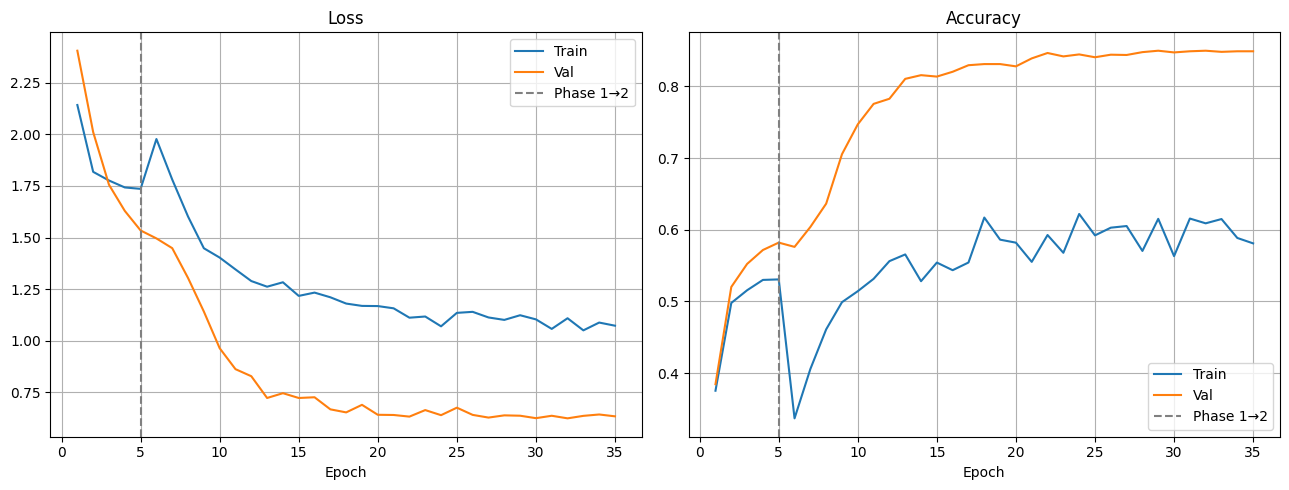

Baseline best val accuracy (01_EDA.ipynb): 0.4385
This model's best val accuracy: 0.8497


In [15]:
import matplotlib.pyplot as plt

full_history = {k: history_p1[k] + history_p2[k] for k in history_p1}
epochs_range = range(1, len(full_history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs_range, full_history["train_loss"], label="Train")
axes[0].plot(epochs_range, full_history["val_loss"], label="Val")
axes[0].axvline(len(history_p1["train_loss"]), color="gray", linestyle="--", label="Phase 1→2")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, full_history["train_acc"], label="Train")
axes[1].plot(epochs_range, full_history["val_acc"], label="Val")
axes[1].axvline(len(history_p1["train_acc"]), color="gray", linestyle="--", label="Phase 1→2")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

print("Baseline best val accuracy (01_EDA.ipynb): 0.4385")
print(f"This model's best val accuracy: {max(val_acc_p1, val_acc_p2):.4f}")

In [16]:
checkpoint_path = "/content/drive/MyDrive/har_effnetv2s_finetuned.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "architecture": "efficientnet_v2_s",
    "num_classes": NUM_CLASSES,
    "class_to_idx": class_to_idx,
    "input_size": IMG_SIZE,
    "best_val_accuracy": max(val_acc_p1, val_acc_p2),
}, checkpoint_path)
print("Saved to:", checkpoint_path)

Saved to: /content/drive/MyDrive/har_effnetv2s_finetuned.pth


## 5. Standard validation analysis

Same confusion matrix / classification report treatment as the baseline notebook, for a direct
before/after comparison.


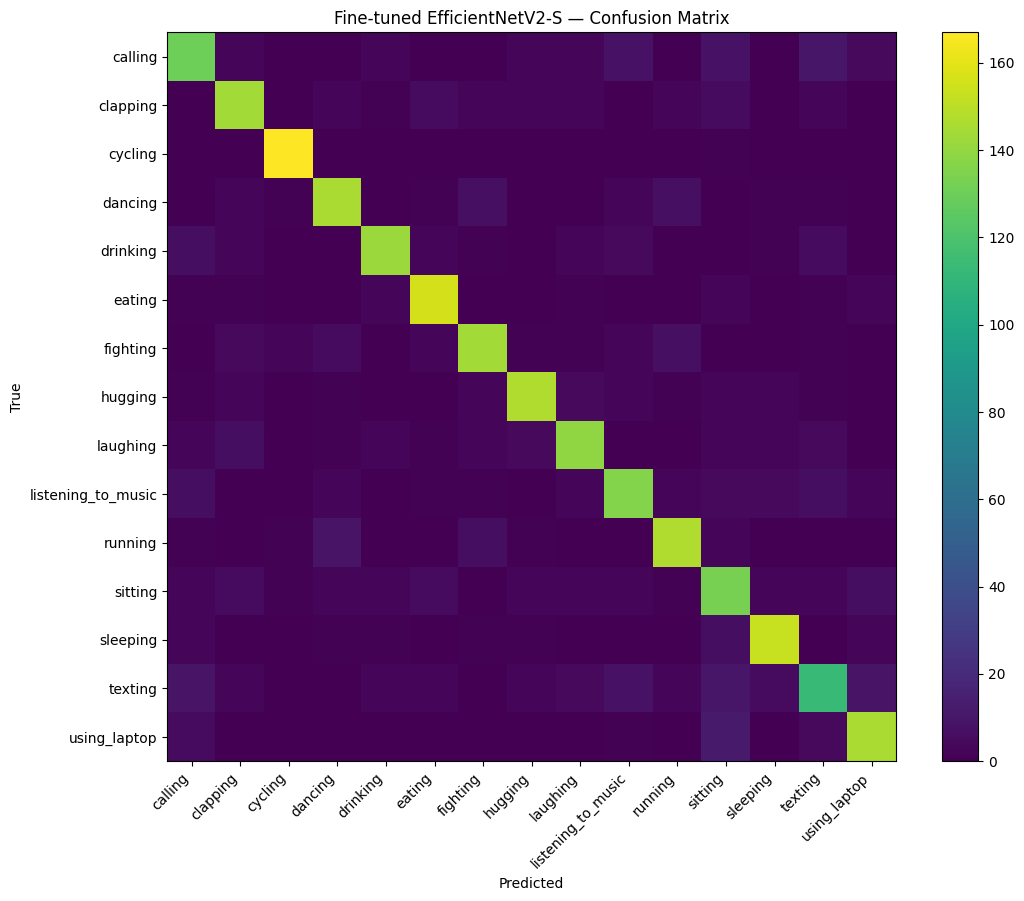

                    precision    recall  f1-score   support

           calling     0.7784    0.7738    0.7761       168
          clapping     0.8372    0.8521    0.8446       169
           cycling     0.9709    0.9940    0.9824       168
           dancing     0.8538    0.8690    0.8614       168
          drinking     0.8987    0.8452    0.8712       168
            eating     0.8864    0.9286    0.9070       168
          fighting     0.8623    0.8521    0.8571       169
           hugging     0.9074    0.8802    0.8936       167
          laughing     0.8634    0.8274    0.8450       168
listening_to_music     0.8242    0.8095    0.8168       168
           running     0.8647    0.8802    0.8724       167
           sitting     0.7074    0.7917    0.7472       168
          sleeping     0.9000    0.9053    0.9027       169
           texting     0.7533    0.6686    0.7085       169
      using_laptop     0.8439    0.8690    0.8563       168

          accuracy                    

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

class_names = classes
all_predictions, all_labels = get_predictions(model, val_loader)

cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(11, 9))
plt.imshow(cm, interpolation="nearest")
plt.title("Fine-tuned EfficientNetV2-S — Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.tight_layout(); plt.show()

print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))

## 6. Wild / OOD robustness suite — the main deliverable

Clean validation accuracy alone does *not* tell us how the model behaves "in the wild." Real-world
images differ from this dataset in lighting, compression, camera shake, partial occlusion, and
framing. To actually measure that gap we build a **corrupted validation benchmark** (in the spirit
of ImageNet-C) with 8 corruption types × 3 severities, evaluate both the baseline and the fine-tuned
model on it, and look at where accuracy falls off a cliff.


In [18]:
import cv2

def add_gaussian_noise(img, severity):
    sigma = [0.03, 0.08, 0.15][severity]
    arr = np.array(img).astype(np.float32) / 255.0
    noisy = arr + np.random.normal(0, sigma, arr.shape)
    return Image.fromarray((np.clip(noisy, 0, 1) * 255).astype(np.uint8))

def add_gaussian_blur(img, severity):
    k = [3, 7, 13][severity]
    arr = cv2.GaussianBlur(np.array(img), (k, k), 0)
    return Image.fromarray(arr)

def add_motion_blur(img, severity):
    k = [5, 11, 17][severity]
    kernel = np.zeros((k, k)); kernel[k // 2, :] = 1.0 / k
    arr = cv2.filter2D(np.array(img), -1, kernel)
    return Image.fromarray(arr)

def adjust_brightness(img, severity):
    factor = [0.6, 0.4, 0.25][severity]  # simulate low light
    return transforms.functional.adjust_brightness(img, factor)

def adjust_contrast(img, severity):
    factor = [0.6, 0.4, 0.25][severity]
    return transforms.functional.adjust_contrast(img, factor)

def jpeg_compress(img, severity):
    quality = [40, 20, 10][severity]
    arr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    _, enc = cv2.imencode(".jpg", arr, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return Image.fromarray(cv2.cvtColor(dec, cv2.COLOR_BGR2RGB))

def occlusion(img, severity):
    frac = [0.15, 0.30, 0.45][severity]  # fraction of shorter side blacked out
    arr = np.array(img).copy()
    h, w = arr.shape[:2]
    size = int(min(h, w) * frac)
    y = np.random.randint(0, max(1, h - size))
    x = np.random.randint(0, max(1, w - size))
    arr[y:y + size, x:x + size] = 0
    return Image.fromarray(arr)

def background_shift(img, severity):
    factor = [0.05, 0.15, 0.3][severity]
    return transforms.functional.adjust_hue(img, factor)
# background_shift is a crude proxy for a different scene (hue rotation on everything).
# A real background-swap needs segmentation; this at least stresses context-shortcut reliance.

CORRUPTIONS = {
    "gaussian_noise": add_gaussian_noise,
    "gaussian_blur": add_gaussian_blur,
    "motion_blur": add_motion_blur,
    "low_light": adjust_brightness,
    "low_contrast": adjust_contrast,
    "jpeg_compression": jpeg_compress,
    "occlusion": occlusion,
    "hue_shift": background_shift,
}
print("Corruption types:", list(CORRUPTIONS.keys()))

Corruption types: ['gaussian_noise', 'gaussian_blur', 'motion_blur', 'low_light', 'low_contrast', 'jpeg_compression', 'occlusion', 'hue_shift']


In [19]:
class CorruptedHARDataset(Dataset):
    """ Applies one corruption at one severity, then the normal (no-augmentation) eval transform. """
    def __init__(self, dataframe, image_dir, corruption_fn, severity):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.corruption_fn = corruption_fn
        self.severity = severity
        self.post = transforms.Compose([
            ResizeWithPadding(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row["filename"])).convert("RGB")
        if self.corruption_fn is not None:
            image = self.corruption_fn(image, self.severity)
        image = self.post(image)
        label = class_to_idx[row["label"]]
        return image, label

In [20]:
def evaluate_robustness(model, dataframe, image_dir, corruptions, severities=(0, 1, 2), batch_size=32):
    results = {}
    for name, fn in corruptions.items():
        for sev in severities:
            ds = CorruptedHARDataset(dataframe, image_dir, fn, sev)
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
            _, acc = evaluate(model, loader)
            results[(name, sev)] = acc
            print(f"{name:18s} severity={sev} -> val_acc={acc:.4f}")
    return results

print("Evaluating fine-tuned model on the wild/OOD benchmark (this will take a while)...")
robustness_results = evaluate_robustness(model, val_split, TRAIN_PATH, CORRUPTIONS)

Evaluating fine-tuned model on the wild/OOD benchmark (this will take a while)...
gaussian_noise     severity=0 -> val_acc=0.8394
gaussian_noise     severity=1 -> val_acc=0.8176
gaussian_noise     severity=2 -> val_acc=0.7839
gaussian_blur      severity=0 -> val_acc=0.8271
gaussian_blur      severity=1 -> val_acc=0.7787
gaussian_blur      severity=2 -> val_acc=0.6923
motion_blur        severity=0 -> val_acc=0.8049
motion_blur        severity=1 -> val_acc=0.6975
motion_blur        severity=2 -> val_acc=0.5571
low_light          severity=0 -> val_acc=0.8466
low_light          severity=1 -> val_acc=0.8410
low_light          severity=2 -> val_acc=0.8406
low_contrast       severity=0 -> val_acc=0.8410
low_contrast       severity=1 -> val_acc=0.8362
low_contrast       severity=2 -> val_acc=0.8347
jpeg_compression   severity=0 -> val_acc=0.8434
jpeg_compression   severity=1 -> val_acc=0.8117
jpeg_compression   severity=2 -> val_acc=0.7728
occlusion          severity=0 -> val_acc=0.8323
occlus

In [21]:
import pandas as pd

rows = []
for (name, sev), acc in robustness_results.items():
    rows.append({"corruption": name, "severity": sev, "val_accuracy": acc})
robustness_df = pd.DataFrame(rows)

clean_acc = evaluate(model, val_loader)[1]
robustness_df = pd.concat([
    pd.DataFrame([{"corruption": "clean", "severity": -1, "val_accuracy": clean_acc}]),
    robustness_df,
], ignore_index=True)

pivot = robustness_df[robustness_df.corruption != "clean"].pivot(
    index="corruption", columns="severity", values="val_accuracy"
)
pivot["mean_over_severity"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean_over_severity")

print(f"Clean validation accuracy: {clean_acc:.4f}")
print()
print(pivot)

mCE_style_score = pivot["mean_over_severity"].mean()
print()
print(f"Mean accuracy across all corruptions/severities ('wild score'): {mCE_style_score:.4f}")
print(f"Robustness gap vs clean: {clean_acc - mCE_style_score:.4f}")

Clean validation accuracy: 0.8497

severity                 0         1         2  mean_over_severity
corruption                                                        
motion_blur       0.804917  0.697462  0.557098            0.686492
gaussian_blur     0.827121  0.778747  0.692308            0.766059
hue_shift         0.832672  0.780730  0.754956            0.789453
occlusion         0.832276  0.800159  0.746233            0.792889
jpeg_compression  0.843378  0.811657  0.772799            0.809278
gaussian_noise    0.839413  0.817605  0.783902            0.813640
low_contrast      0.840999  0.836241  0.834655            0.837298
low_light         0.846550  0.840999  0.840603            0.842717

Mean accuracy across all corruptions/severities ('wild score'): 0.7922
Robustness gap vs clean: 0.0575


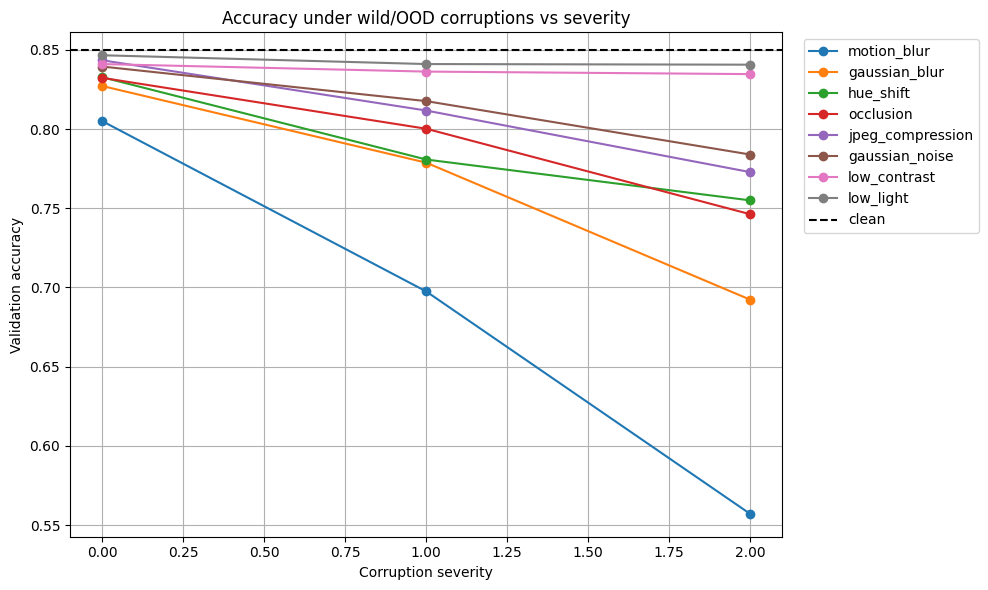

In [22]:
plt.figure(figsize=(10, 6))
for corruption in pivot.index:
    plt.plot([0, 1, 2], pivot.loc[corruption, [0, 1, 2]], marker="o", label=corruption)
plt.axhline(clean_acc, color="black", linestyle="--", label="clean")
plt.xlabel("Corruption severity"); plt.ylabel("Validation accuracy")
plt.title("Accuracy under wild/OOD corruptions vs severity")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True); plt.tight_layout(); plt.show()

**How to read this:** the corruptions the model degrades on fastest (lowest curves,
steepest slope) are the ones telling you *what* the model actually relies on. If `occlusion`
and `hue_shift` cause the biggest drops, that's consistent with the baseline's Grad-CAM finding
that it leans on background/context rather than pose — worth re-running the Grad-CAM cells below
under corruption to check whether fine-tuning actually fixed that or just made the model more
confident about the same shortcut.


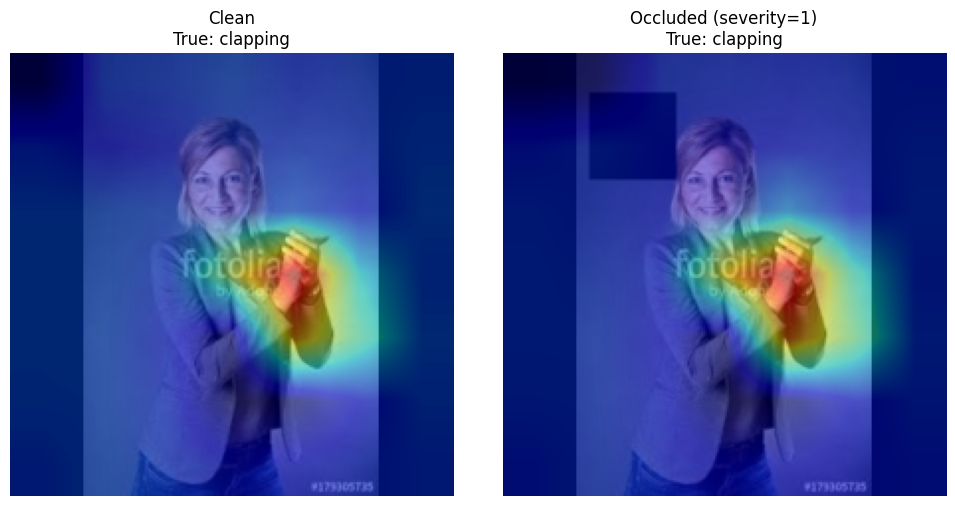

In [23]:
def generate_gradcam(model, image_tensor, target_class, target_layer):
    model.eval()
    activations, gradients = [], []

    def forward_hook(module, inp, out):
        activations.append(out)
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    image_tensor = image_tensor.unsqueeze(0).to(device)
    output = model(image_tensor)
    model.zero_grad()
    output[0, target_class].backward()

    activation = activations[0].detach()
    gradient = gradients[0].detach()
    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * activation).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    fh.remove(); bh.remove()
    return cam

def denormalize(image_tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    return torch.clamp(image, 0, 1).permute(1, 2, 0).numpy()

# EfficientNetV2-S's last conv block, for Grad-CAM
gradcam_layer = model.features[-1]

sample_row = val_split.iloc[0]
clean_img = Image.open(os.path.join(TRAIN_PATH, sample_row["filename"])).convert("RGB")
occluded_img = occlusion(clean_img, severity=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, title in zip(axes, [clean_img, occluded_img], ["Clean", "Occluded (severity=1)"]):
    tensor = val_transform(img)
    true_idx = class_to_idx[sample_row["label"]]
    cam = generate_gradcam(model, tensor, true_idx, gradcam_layer)
    ax.imshow(denormalize(tensor))
    ax.imshow(cam, cmap="jet", alpha=0.45)
    ax.set_title(f"{title}\nTrue: {sample_row['label']}")
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Multi-step (hierarchical) classification

Idea: instead of one 15-way classifier, split the problem into a coarse stage that's easy to get
right (fewer, more visually distinct groups) and a fine stage that only has to disambiguate within
a group. This directly targets the baseline's worst confusion cluster
(`sitting` / `calling` / `using_laptop` / `texting` / `listening_to_music` all collapsing toward
`using_laptop`) by giving the model an explicit "these are all screen/seated activities" grouping
to reason within, rather than competing against `cycling` or `fighting` in the same softmax.


In [24]:
# Coarse grouping - adjust based on what the confusion matrix above actually shows
COARSE_GROUPS = {
    "seated_screen":     ["sitting", "using_laptop", "texting", "calling", "listening_to_music"],
    "solo_dynamic":      ["running", "cycling", "dancing", "sleeping"],
    "interpersonal":     ["hugging", "fighting", "laughing", "clapping"],
    "eating_drinking":   ["eating", "drinking"],
}
FINE_TO_COARSE = {fine: coarse for coarse, fines in COARSE_GROUPS.items() for fine in fines}

# sanity check every class got a group
missing = set(classes) - set(FINE_TO_COARSE)
assert not missing, f"Unassigned classes, fix COARSE_GROUPS: {missing}"

coarse_classes = sorted(COARSE_GROUPS.keys())
coarse_to_idx = {c: i for i, c in enumerate(coarse_classes)}

train_split["coarse_label"] = train_split["label"].map(FINE_TO_COARSE)
val_split["coarse_label"] = val_split["label"].map(FINE_TO_COARSE)
print(train_split["coarse_label"].value_counts())

coarse_label
seated_screen      3359
solo_dynamic       2688
interpersonal      2687
eating_drinking    1344
Name: count, dtype: int64


In [25]:
class HierarchicalModel(nn.Module):
    """ Shared EfficientNet-V2-S trunk, two heads: coarse group + fine class. Fine logits are
    additively biased toward the predicted coarse group's members at inference time. """
    def __init__(self, num_coarse, num_fine, dropout=0.3):
        super().__init__()
        weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
        backbone = efficientnet_v2_s(weights=weights)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.trunk = backbone
        self.dropout = nn.Dropout(dropout)
        self.coarse_head = nn.Linear(in_features, num_coarse)
        self.fine_head = nn.Linear(in_features, num_fine)

    def forward(self, x):
        feats = self.dropout(self.trunk(x))
        return self.coarse_head(feats), self.fine_head(feats)


hier_model = HierarchicalModel(len(coarse_classes), NUM_CLASSES).to(device)

# Group-mask: which fine classes are valid for each coarse group (for the inference-time bias)
group_mask = torch.zeros(len(coarse_classes), NUM_CLASSES)
for coarse, fines in COARSE_GROUPS.items():
    for f in fines:
        group_mask[coarse_to_idx[coarse], class_to_idx[f]] = 1.0
group_mask = group_mask.to(device)
print(group_mask.shape)

torch.Size([4, 15])


In [26]:
class HARDatasetHier(HARDataset):
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row["filename"])).convert("RGB")
        fine_label = class_to_idx[row["label"]]
        coarse_label = coarse_to_idx[row["coarse_label"]]
        if self.transform:
            image = self.transform(image)
        return image, fine_label, coarse_label


hier_train_ds = HARDatasetHier(train_split, TRAIN_PATH, transform=train_transform)
hier_val_ds   = HARDatasetHier(val_split, TRAIN_PATH, transform=val_transform)
hier_train_loader = DataLoader(hier_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
hier_val_loader   = DataLoader(hier_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


def train_hierarchical(model, train_loader, val_loader, epochs=25, lr_head=5e-4, lr_backbone=5e-5,
                        coarse_weight=0.3, patience=6):
    param_groups = [
        {"params": list(model.coarse_head.parameters()) + list(model.fine_head.parameters()), "lr": lr_head},
        {"params": model.trunk.parameters(), "lr": lr_backbone},
    ]
    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    total_steps = epochs * len(train_loader)
    scheduler = cosine_warmup_scheduler(optimizer, warmup_steps=int(0.05 * total_steps), total_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler()

    best_acc, best_state, no_improve = 0.0, None, 0

    for epoch in range(epochs):
        model.train()
        for images, fine_labels, coarse_labels in train_loader:
            images = images.to(device); fine_labels = fine_labels.to(device); coarse_labels = coarse_labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                coarse_logits, fine_logits = model(images)
                loss = (F.cross_entropy(fine_logits, fine_labels, label_smoothing=0.1)
                        + coarse_weight * F.cross_entropy(coarse_logits, coarse_labels, label_smoothing=0.1))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); scheduler.step()

        acc = evaluate_hierarchical(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | hierarchical val fine-acc={acc:.4f}")
        if acc > best_acc:
            best_acc, best_state, no_improve = acc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping."); break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_acc


@torch.no_grad()
def evaluate_hierarchical(model, loader, bias_strength=2.0):
    model.eval()
    correct, total = 0, 0
    for images, fine_labels, coarse_labels in loader:
        images = images.to(device); fine_labels = fine_labels.to(device)
        coarse_logits, fine_logits = model(images)
        coarse_pred = coarse_logits.argmax(dim=1)
        bias = group_mask[coarse_pred] * bias_strength
        fine_pred = (fine_logits + bias).argmax(dim=1)
        correct += (fine_pred == fine_labels).sum().item()
        total += fine_labels.size(0)
    return correct / total


hier_model, hier_best_acc = train_hierarchical(hier_model, hier_train_loader, hier_val_loader)
print()
print(f"Flat fine-tuned model best val acc: {max(val_acc_p1, val_acc_p2):.4f}")
print(f"Hierarchical model best val acc:     {hier_best_acc:.4f}")

/tmp/ipykernel_929/2587736785.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_929/2587736785.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/25 | hierarchical val fine-acc=0.6312
Epoch 2/25 | hierarchical val fine-acc=0.7672
Epoch 3/25 | hierarchical val fine-acc=0.8002
Epoch 4/25 | hierarchical val fine-acc=0.8113
Epoch 5/25 | hierarchical val fine-acc=0.8259
Epoch 6/25 | hierarchical val fine-acc=0.8259
Epoch 7/25 | hierarchical val fine-acc=0.8275
Epoch 8/25 | hierarchical val fine-acc=0.8228
Epoch 9/25 | hierarchical val fine-acc=0.8358
Epoch 10/25 | hierarchical val fine-acc=0.8430
Epoch 11/25 | hierarchical val fine-acc=0.8390
Epoch 12/25 | hierarchical val fine-acc=0.8327
Epoch 13/25 | hierarchical val fine-acc=0.8386
Epoch 14/25 | hierarchical val fine-acc=0.8382
Epoch 15/25 | hierarchical val fine-acc=0.8406
Epoch 16/25 | hierarchical val fine-acc=0.8422
Early stopping.

Flat fine-tuned model best val acc: 0.8497
Hierarchical model best val acc:     0.8430


If the hierarchical accuracy beats the flat model, keep it and re-run the confusion-matrix
and wild/OOD cells above on `hier_model` (swap the `evaluate` calls for `evaluate_hierarchical`).
If it doesn't beat the flat model, that itself is a useful negative result worth writing up — it
tells you the confusion isn't really about missing hierarchy, and effort is better spent on data
(more occlusion-heavy training examples, hard-negative mining, etc).


## 8. Incremental training utility

For adding a new dataset/new classes later without retraining from scratch and without catastrophic
forgetting of the original 15 classes. Two ingredients:
- **Replay**: keep a small buffer of original-class examples and mix them into the new training data.
- **Low LR + short schedule** on the already-trained checkpoint, so old representations shift as
  little as possible.


In [27]:
def build_replay_buffer(dataframe, per_class=40, seed=42):
    return (dataframe.groupby("label", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), per_class), random_state=seed))
            .reset_index(drop=True))


def incremental_finetune(model, checkpoint_path, new_df, new_image_dir, old_train_df,
                          replay_per_class=40, epochs=8, lr_head=2e-4, lr_backbone=2e-5):
    # model            : an already-trained model (e.g. `model` from section 4)
    # checkpoint_path  : path to save the updated checkpoint
    # new_df           : dataframe for the NEW data (needs 'filename' and 'label' columns;
    #                    new labels must be added to class_to_idx before calling this)
    # new_image_dir    : image directory for the new data
    # old_train_df     : the ORIGINAL train_split, used to build the replay buffer
    replay_df = build_replay_buffer(old_train_df, per_class=replay_per_class)

    combined_new = HARDataset(new_df, new_image_dir, transform=train_transform)
    combined_replay = HARDataset(replay_df, TRAIN_PATH, transform=train_transform)
    combined_ds = torch.utils.data.ConcatDataset([combined_new, combined_replay])
    combined_loader = DataLoader(combined_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=2, drop_last=True)

    model, history, best_acc = train_one_phase(
        model, combined_loader, val_loader,  # still validate against the original held-out set
        epochs=epochs, head_lr=lr_head, backbone_lr=lr_backbone,
        use_mixup=False, patience=4,
    )

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_to_idx": class_to_idx,
        "num_classes": len(class_to_idx),
    }, checkpoint_path)

    print(f"Incremental checkpoint saved to {checkpoint_path}. "
          f"Val accuracy on original held-out set after update: {best_acc:.4f}")
    return model, history

# Usage once a new dataset is available, e.g.:
# for new_label in new_df["label"].unique():
#     if new_label not in class_to_idx:
#         class_to_idx[new_label] = len(class_to_idx)
#         idx_to_class[class_to_idx[new_label]] = new_label
# model = expand_classifier_head(model, new_num_classes=len(class_to_idx))  # implement per architecture
# model, _ = incremental_finetune(model, "/content/drive/MyDrive/har_v2.pth", new_df, NEW_IMAGE_DIR, train_split)
print("Incremental-training utility defined. Call incremental_finetune(...) once new data exists.")

Incremental-training utility defined. Call incremental_finetune(...) once new data exists.


## 9. Train on what you evaluate on: corruption-aware fine-tuning

The single biggest lever for OOD robustness is usually just this: if the model never sees noise,
blur, low light, or occlusion during training, it has no reason to be robust to them. So we take
the Section 6 corruption functions and fold them into the *training* pipeline as one more
augmentation choice, then do a short additional fine-tune (Phase 3) starting from the
already-trained checkpoint.

Two design choices worth calling out:
- Corruptions are applied **stochastically and at random severity**, mixed in with the existing
  TrivialAugmentWide/RandomErasing pipeline — not as a wholesale replacement of it. The goal is a
  model that's robust to corruption, not a model that's only ever seen corrupted images.
- We keep a **clean-only held-out validation set** (the original `val_loader`) so we can tell
  whether Phase 3 is actually improving generalization vs. just overfitting to the corruption
  distribution we happened to pick.


In [28]:
import random

class WildTrainTransform:
    """ Aspect-ratio resize + standard augmentation + a randomly-applied wild corruption
    (from Section 6) at a random severity, so training distribution matches the eval distribution. """
    def __init__(self, size, corruption_prob=0.5):
        self.resize = ResizeWithPadding(size)
        self.corruption_prob = corruption_prob
        self.corruption_fns = list(CORRUPTIONS.values())
        self.standard_aug = transforms.TrivialAugmentWide()
        self.to_tensor_norm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ])
        self.random_erasing = transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))

    def __call__(self, image):
        image = self.resize(image)

        if random.random() < self.corruption_prob:
            corrupt_fn = random.choice(self.corruption_fns)
            severity = random.randint(0, 2)
            image = corrupt_fn(image, severity)
        else:
            image = self.standard_aug(image)

        tensor = self.to_tensor_norm(image)
        tensor = self.random_erasing(tensor)
        return tensor


wild_train_transform = WildTrainTransform(IMG_SIZE, corruption_prob=0.5)

wild_train_dataset = HARDataset(train_split, TRAIN_PATH, transform=wild_train_transform)
wild_train_loader = DataLoader(wild_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=2, pin_memory=True, drop_last=True)
print("Wild-augmented training batches:", len(wild_train_loader))

Wild-augmented training batches: 314


In [29]:
# Phase 3 - short corruption-aware fine-tune from the Phase-2 checkpoint, low LR so we
# adapt to the wider distribution without forgetting what Phase 2 already learned.
model, history_p3, val_acc_p3 = train_one_phase(
    model, wild_train_loader, val_loader,   # still validated on CLEAN val data
    epochs=10, head_lr=2e-4, backbone_lr=2e-5,
    use_mixup=True, patience=4,
)
print("Phase 3 (corruption-aware) best CLEAN val acc:", val_acc_p3)

/tmp/ipykernel_929/2292080447.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_929/2292080447.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10 | train_loss=1.1420 train_acc=0.6147 | val_loss=0.6480 val_acc=0.8402
Epoch 2/10 | train_loss=1.1859 train_acc=0.5764 | val_loss=0.6375 val_acc=0.8434
Epoch 3/10 | train_loss=1.1965 train_acc=0.5590 | val_loss=0.6443 val_acc=0.8386
Epoch 4/10 | train_loss=1.0810 train_acc=0.5854 | val_loss=0.6401 val_acc=0.8398
Epoch 5/10 | train_loss=1.0996 train_acc=0.6002 | val_loss=0.6467 val_acc=0.8418
Epoch 6/10 | train_loss=1.0876 train_acc=0.6220 | val_loss=0.6199 val_acc=0.8422
Early stopping at epoch 6 (no improvement for 4 epochs).
Phase 3 (corruption-aware) best CLEAN val acc: 0.8433782712133228


In [30]:
# Re-run the Section 6 robustness benchmark to see whether Phase 3 actually helped
print("Evaluating corruption-aware model on the wild/OOD benchmark...")
robustness_results_v2 = evaluate_robustness(model, val_split, TRAIN_PATH, CORRUPTIONS)

rows_v2 = [{"corruption": name, "severity": sev, "val_accuracy": acc}
           for (name, sev), acc in robustness_results_v2.items()]
robustness_df_v2 = pd.DataFrame(rows_v2)

pivot_v2 = robustness_df_v2.pivot(index="corruption", columns="severity", values="val_accuracy")
pivot_v2["mean_over_severity"] = pivot_v2.mean(axis=1)

comparison = pd.DataFrame({
    "before_phase3": pivot["mean_over_severity"],
    "after_phase3": pivot_v2["mean_over_severity"],
})
comparison["delta"] = comparison["after_phase3"] - comparison["before_phase3"]
comparison = comparison.sort_values("delta")

clean_acc_v2 = evaluate(model, val_loader)[1]
print(f"Clean val accuracy: before={clean_acc:.4f}  after={clean_acc_v2:.4f}")
print()
print(comparison)
print()
print(f"Wild score: before={pivot['mean_over_severity'].mean():.4f}  "
      f"after={pivot_v2['mean_over_severity'].mean():.4f}")

Evaluating corruption-aware model on the wild/OOD benchmark...
gaussian_noise     severity=0 -> val_acc=0.8406
gaussian_noise     severity=1 -> val_acc=0.8192
gaussian_noise     severity=2 -> val_acc=0.7784
gaussian_blur      severity=0 -> val_acc=0.8247
gaussian_blur      severity=1 -> val_acc=0.7926
gaussian_blur      severity=2 -> val_acc=0.7324
motion_blur        severity=0 -> val_acc=0.8140
motion_blur        severity=1 -> val_acc=0.7514
motion_blur        severity=2 -> val_acc=0.6733
low_light          severity=0 -> val_acc=0.8442
low_light          severity=1 -> val_acc=0.8422
low_light          severity=2 -> val_acc=0.8374
low_contrast       severity=0 -> val_acc=0.8366
low_contrast       severity=1 -> val_acc=0.8374
low_contrast       severity=2 -> val_acc=0.8366
jpeg_compression   severity=0 -> val_acc=0.8390
jpeg_compression   severity=1 -> val_acc=0.8156
jpeg_compression   severity=2 -> val_acc=0.7855
occlusion          severity=0 -> val_acc=0.8295
occlusion          severi

If `after_phase3` beats `before_phase3` on most corruptions with only a small clean-accuracy
cost, keep this checkpoint as the final model and re-save it (overwrite the checkpoint cell from
Section 4). If clean accuracy dropped a lot, lower `corruption_prob` in `WildTrainTransform` (e.g.
0.3) and shorten Phase 3, or reduce `use_mixup` — you're likely over-corrupting relative to how
much clean signal the model needs to keep.


## 10. Test-time augmentation (TTA)

A free accuracy bump with **no retraining**: run several augmented views of each validation image
through the model and average the softmax probabilities. Useful both as a quick win in production
and as a diagnostic — if TTA closes a lot of the wild/OOD gap, the model already "knows" the right
answer some of the time and is just sensitive to exact framing/crop, which is a much cheaper
problem to solve than a genuine representation gap.


In [31]:
def build_tta_transforms(size):
    """ Five views: center resize, horizontal flip, and three re-crops after padding
    slightly larger than the target size (so crops actually move the content, not just re-sample
    the same padding border). """
    pad_size = int(size * 1.14)  # ~256 for size=224, matches the classic ImageNet TTA ratio

    base = ResizeWithPadding(pad_size)
    to_tensor_norm = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

    def center_crop(img):
        img = base(img)
        return transforms.functional.center_crop(img, size)

    def flip_crop(img):
        img = base(img)
        img = transforms.functional.hflip(img)
        return transforms.functional.center_crop(img, size)

    def corner_crop(img, corner):
        img = base(img)
        w, h = img.size
        if corner == "tl":
            box = (0, 0, size, size)
        elif corner == "tr":
            box = (w - size, 0, w, size)
        else:  # "bl"
            box = (0, h - size, size, h)
        return img.crop(box)

    views = [
        lambda img: to_tensor_norm(center_crop(img)),
        lambda img: to_tensor_norm(flip_crop(img)),
        lambda img: to_tensor_norm(corner_crop(img, "tl")),
        lambda img: to_tensor_norm(corner_crop(img, "tr")),
        lambda img: to_tensor_norm(corner_crop(img, "bl")),
    ]
    return views


tta_views = build_tta_transforms(IMG_SIZE)
print(f"{len(tta_views)} TTA views defined.")

5 TTA views defined.


In [32]:
@torch.no_grad()
def predict_tta(model, image, tta_views):
    model.eval()
    probs_sum = None
    for view_fn in tta_views:
        tensor = view_fn(image).unsqueeze(0).to(device)
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)
        probs_sum = probs if probs_sum is None else probs_sum + probs
    return (probs_sum / len(tta_views)).squeeze(0)


def evaluate_tta(model, dataframe, image_dir, tta_views, corruption_fn=None, severity=0):
    model.eval()
    correct, total = 0, 0
    for _, row in dataframe.iterrows():
        image = Image.open(os.path.join(image_dir, row["filename"])).convert("RGB")
        if corruption_fn is not None:
            image = corruption_fn(image, severity)
        probs = predict_tta(model, image, tta_views)
        pred = probs.argmax().item()
        correct += int(pred == class_to_idx[row["label"]])
        total += 1
    return correct / total


# NOTE: this loops one image at a time (simplicity over speed) - fine for the ~2.5k validation
# set, but for a bigger set batch the views together instead.
print("Evaluating TTA on clean validation data (this is slower than a normal batched eval)...")
tta_clean_acc = evaluate_tta(model, val_split, TRAIN_PATH, tta_views)
print(f"Clean val accuracy: single-view={clean_acc_v2 if 'clean_acc_v2' in dir() else clean_acc:.4f}  "
      f"TTA={tta_clean_acc:.4f}")

Evaluating TTA on clean validation data (this is slower than a normal batched eval)...
Clean val accuracy: single-view=0.8434  TTA=0.8541


In [33]:
# Check whether TTA also helps under the hardest wild/OOD corruptions - use the same
# corruption functions at their strongest severity (2).
tta_wild_results = {}
for name, fn in CORRUPTIONS.items():
    acc = evaluate_tta(model, val_split, TRAIN_PATH, tta_views, corruption_fn=fn, severity=2)
    tta_wild_results[name] = acc
    print(f"{name:18s} severity=2 -> TTA val_acc={acc:.4f}  "
          f"(single-view was {pivot_v2.loc[name, 2]:.4f})")

tta_summary = pd.DataFrame({
    "single_view_sev2": pivot_v2[2],
    "tta_sev2": pd.Series(tta_wild_results),
})
tta_summary["tta_gain"] = tta_summary["tta_sev2"] - tta_summary["single_view_sev2"]
print()
print(tta_summary.sort_values("tta_gain"))

gaussian_noise     severity=2 -> TTA val_acc=0.7879  (single-view was 0.7784)
gaussian_blur      severity=2 -> TTA val_acc=0.7335  (single-view was 0.7324)
motion_blur        severity=2 -> TTA val_acc=0.6709  (single-view was 0.6733)
low_light          severity=2 -> TTA val_acc=0.8565  (single-view was 0.8374)
low_contrast       severity=2 -> TTA val_acc=0.8509  (single-view was 0.8366)
jpeg_compression   severity=2 -> TTA val_acc=0.7930  (single-view was 0.7855)
occlusion          severity=2 -> TTA val_acc=0.7827  (single-view was 0.7692)
hue_shift          severity=2 -> TTA val_acc=0.7910  (single-view was 0.7780)

                  single_view_sev2  tta_sev2  tta_gain
motion_blur               0.673275  0.670896 -0.002379
gaussian_blur             0.732355  0.733545  0.001190
jpeg_compression          0.785488  0.793021  0.007534
gaussian_noise            0.778351  0.787867  0.009516
hue_shift                 0.777954  0.791039  0.013085
occlusion                 0.769231  0.782712 

## 11. Mining hard examples per corruption

Same error-gallery idea as the `pairs_to_view` cells in `01_EDA.ipynb`, but driven by *which
corruption* caused the mistake rather than just true/predicted label pairs. This tells you whether
a weak spot is a **modeling** problem (fixable with more training) or a **data** problem (that
class just doesn't have enough occluded/dark/blurry examples for the model to have ever learned
what it looks like under those conditions).


In [34]:
@torch.no_grad()
def collect_corruption_errors(model, dataframe, image_dir, corruption_fn, severity):
    model.eval()
    errors = []
    ds = CorruptedHARDataset(dataframe, image_dir, corruption_fn, severity)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)

    df_reset = dataframe.reset_index(drop=True)
    offset = 0
    for images, labels in loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        wrong_mask = preds != labels
        for i in torch.nonzero(wrong_mask).flatten().tolist():
            row = df_reset.iloc[offset + i]
            errors.append({
                "filename": row["filename"],
                "true_label": row["label"],
                "predicted_label": class_names[preds[i].item()],
            })
        offset += len(labels)
    return pd.DataFrame(errors)


# Per-corruption error counts at the hardest severity, to spot which classes break down where
per_corruption_error_counts = {}
for name, fn in CORRUPTIONS.items():
    err_df = collect_corruption_errors(model, val_split, TRAIN_PATH, fn, severity=2)
    per_corruption_error_counts[name] = err_df["true_label"].value_counts()
    print(f"{name}: {len(err_df)} errors at severity=2")

error_count_table = pd.DataFrame(per_corruption_error_counts).fillna(0).astype(int)
error_count_table["total"] = error_count_table.sum(axis=1)
print()
print(error_count_table.sort_values("total", ascending=False))

gaussian_noise: 548 errors at severity=2
gaussian_blur: 675 errors at severity=2
motion_blur: 824 errors at severity=2
low_light: 410 errors at severity=2
low_contrast: 412 errors at severity=2
jpeg_compression: 541 errors at severity=2
occlusion: 623 errors at severity=2
hue_shift: 560 errors at severity=2

                    gaussian_noise  gaussian_blur  motion_blur  low_light  \
true_label                                                                  
texting                         67             66           77         52   
listening_to_music              50             77          102         35   
sitting                         44             52           84         39   
calling                         43             47           74         40   
laughing                        50             68           42         36   
hugging                         35             49           56         19   
using_laptop                    54             59           62         24 

In [35]:
# Cross-reference against how many TRAINING examples of each class already contain something
# close to that corruption naturally (rough proxy: brightness/contrast/blur statistics), or --
# simpler and more actionable -- just check raw per-class training counts, since this dataset is
# balanced (840/class) any imbalance you see here is coming from the corruption sensitivity
# itself, not from having fewer images of that class to begin with.
class_counts = train_split["label"].value_counts()
diagnostic = pd.DataFrame({
    "n_train_images": class_counts,
    "total_corruption_errors": error_count_table["total"],
})
diagnostic["errors_per_100_train_images"] = (
    diagnostic["total_corruption_errors"] / diagnostic["n_train_images"] * 100
)
print(diagnostic.sort_values("errors_per_100_train_images", ascending=False))
print()
print("Classes at the top of this table break down under corruption despite having the SAME")
print("amount of training data as everything else -> that's a modeling/representation issue,")
print("not a data-quantity issue. Consider hard-negative mining or targeted corruption-heavy")
print("augmentation for specifically those classes, rather than collecting more raw images.")

                    n_train_images  total_corruption_errors  \
texting                        671                      529   
listening_to_music             672                      437   
sitting                        672                      419   
calling                        672                      383   
laughing                       672                      354   
using_laptop                   672                      317   
hugging                        673                      317   
drinking                       672                      315   
dancing                        672                      308   
fighting                       671                      258   
clapping                       671                      248   
sleeping                       671                      227   
eating                         672                      215   
running                        673                      202   
cycling                        672                     

In [ ]:
# Visual gallery: worst class under its worst corruption
worst_class = diagnostic["errors_per_100_train_images"].idxmax()
worst_corruption = error_count_table.drop(columns="total").loc[worst_class].idxmax()
print(f"Worst combination: class='{worst_class}' under corruption='{worst_corruption}'")

fn = CORRUPTIONS[worst_corruption]
err_df = collect_corruption_errors(model, val_split, TRAIN_PATH, fn, severity=2)
gallery_df = err_df[err_df["true_label"] == worst_class].head(6)

fig, axes = plt.subplots(1, len(gallery_df), figsize=(4 * len(gallery_df), 4))
if len(gallery_df) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, gallery_df.iterrows()):
    image = Image.open(os.path.join(TRAIN_PATH, row["filename"])).convert("RGB")
    corrupted = fn(image, 2)
    ax.imshow(corrupted)
    ax.set_title(f"True: {row['true_label']}\nPred: {row['predicted_label']}", fontsize=10)
    ax.axis("off")

plt.suptitle(f"Hardest failure mode: {worst_class} under {worst_corruption} (severity 2)")
plt.tight_layout(); plt.show()

Worst combination: class='texting' under corruption='motion_blur'


**Reading this gallery:** if the true action is still visually obvious to *you* in these
images, it's a training-signal problem — add this corruption type (at this severity) more heavily
into `WildTrainTransform` for this specific class, or oversample it. If the action genuinely looks
ambiguous or unrecognizable even to a human at this corruption severity, that's a ceiling on what
any model can do here, and it's more honest to report that limitation than to keep pushing training
against it.


## 12. AugMix + Jensen-Shannon consistency training (stronger than naive corruption training)

Section 9's approach — mixing corruptions directly into training — helps, but there's a
better-studied technique for this exact problem: **AugMix** (Hendrycks et al., 2020), the method
that set the ImageNet-C corruption-robustness state of the art at the time it was published. The
difference from Section 9 isn't just the augmentation itself — `torchvision.transforms.AugMix`
composites several randomly-weighted augmentation chains together, which produces more diverse,
less "single-corruption-shaped" perturbations than applying one corruption at a time — it's the
**training objective**:

1. Produce three views of each image: the clean version, and two independently AugMix'd versions.
2. Forward all three through the model.
3. Train with the normal classification loss on the clean view, **plus** a Jensen-Shannon
   divergence term that pulls all three views' output distributions toward their average.

That consistency term is what actually teaches the model "these should all mean the same thing,"
which generalizes to corruption types the model never saw a labeled example of — including several
of the ones in our Section 6 benchmark. It costs 3x the forward passes per batch, so budget for a
shorter run.


In [ ]:
from torch.optim.swa_utils import AveragedModel, SWALR

augmix_view = transforms.Compose([
    ResizeWithPadding(IMG_SIZE),
    transforms.AugMix(severity=3, mixture_width=3),
])
clean_view = transforms.Compose([
    ResizeWithPadding(IMG_SIZE),
])
to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class JSDTripleDataset(Dataset):
    """ Returns (clean_tensor, augmix1_tensor, augmix2_tensor, label) for AugMix + JSD training. """
    def __init__(self, dataframe, image_dir):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row["filename"])).convert("RGB")
        label = class_to_idx[row["label"]]

        clean = to_tensor_norm(clean_view(image))
        aug1 = to_tensor_norm(augmix_view(image))
        aug2 = to_tensor_norm(augmix_view(image))
        return clean, aug1, aug2, label


jsd_train_dataset = JSDTripleDataset(train_split, TRAIN_PATH)
jsd_train_loader = DataLoader(jsd_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True, drop_last=True)
print("JSD training batches:", len(jsd_train_loader), "(3 forward passes per batch)")

In [ ]:
def jsd_consistency_loss(logits_clean, logits_aug1, logits_aug2):
    p_clean = F.softmax(logits_clean, dim=1)
    p_aug1 = F.softmax(logits_aug1, dim=1)
    p_aug2 = F.softmax(logits_aug2, dim=1)

    p_mixture = torch.clamp((p_clean + p_aug1 + p_aug2) / 3.0, 1e-7, 1.0).log()

    loss = (
        F.kl_div(p_mixture, p_clean, reduction="batchmean")
        + F.kl_div(p_mixture, p_aug1, reduction="batchmean")
        + F.kl_div(p_mixture, p_aug2, reduction="batchmean")
    ) / 3.0
    return loss


def train_augmix_jsd(model, train_loader, val_loader, epochs=12, head_lr=2e-4, backbone_lr=2e-5,
                      jsd_weight=6.0, patience=4, swa_start_frac=0.6):
    """ Phase 4: AugMix + JSD consistency fine-tune from the Phase-3 checkpoint, with SWA
    activated for the back half of training for an extra generalization boost at no inference cost. """
    optimizer = torch.optim.AdamW([
        {"params": [p for n, p in model.named_parameters() if n.startswith("classifier")], "lr": head_lr},
        {"params": [p for n, p in model.named_parameters() if not n.startswith("classifier")], "lr": backbone_lr},
    ], weight_decay=1e-4)

    total_steps = epochs * len(train_loader)
    scheduler = cosine_warmup_scheduler(optimizer, warmup_steps=int(0.05 * total_steps), total_steps=total_steps)
    scaler = torch.cuda.amp.GradScaler()

    swa_model = AveragedModel(model)
    swa_start_epoch = int(epochs * swa_start_frac)
    swa_scheduler = SWALR(optimizer, swa_lr=head_lr * 0.5)

    best_acc, best_state, no_improve = 0.0, None, 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for clean, aug1, aug2, labels in train_loader:
            clean, aug1, aug2 = clean.to(device), aug1.to(device), aug2.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                batch = torch.cat([clean, aug1, aug2], dim=0)
                logits = model(batch)
                logits_clean, logits_aug1, logits_aug2 = logits.chunk(3, dim=0)

                ce_loss = F.cross_entropy(logits_clean, labels, label_smoothing=0.1)
                jsd_loss = jsd_consistency_loss(logits_clean, logits_aug1, logits_aug2)
                loss = ce_loss + jsd_weight * jsd_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            if epoch >= swa_start_epoch:
                swa_scheduler.step()
            else:
                scheduler.step()

            running_loss += loss.item()

        if epoch >= swa_start_epoch:
            swa_model.update_parameters(model)

        eval_model = swa_model.module if epoch >= swa_start_epoch else model
        _, val_acc = evaluate(eval_model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | loss={running_loss/len(train_loader):.4f} | "
              f"val_acc={val_acc:.4f}{' (SWA)' if epoch >= swa_start_epoch else ''}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(eval_model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping.")
                break

    if swa_start_epoch < epochs:
        torch.optim.swa_utils.update_bn(train_loader_for_bn_update, swa_model, device=device)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_acc

`update_bn` needs a plain (non-JSD-triple) loader to recompute BatchNorm statistics for the
SWA-averaged weights — reuse the Section 9 `wild_train_loader` (or `train_loader`) for that,
assigned below before running Phase 4.


In [ ]:
train_loader_for_bn_update = wild_train_loader  # any loader yielding (image, label) batches works

model, val_acc_p4 = train_augmix_jsd(
    model, jsd_train_loader, val_loader,
    epochs=12, head_lr=2e-4, backbone_lr=2e-5, jsd_weight=6.0, patience=4,
)
print("Phase 4 (AugMix + JSD + SWA) best CLEAN val acc:", val_acc_p4)

In [ ]:
# Re-run the full wild/OOD benchmark once more to see the cumulative effect of Phase 3 + Phase 4
print("Evaluating AugMix+JSD+SWA model on the wild/OOD benchmark...")
robustness_results_v3 = evaluate_robustness(model, val_split, TRAIN_PATH, CORRUPTIONS)

rows_v3 = [{"corruption": name, "severity": sev, "val_accuracy": acc}
           for (name, sev), acc in robustness_results_v3.items()]
pivot_v3 = pd.DataFrame(rows_v3).pivot(index="corruption", columns="severity", values="val_accuracy")
pivot_v3["mean_over_severity"] = pivot_v3.mean(axis=1)

full_comparison = pd.DataFrame({
    "phase2_flat": pivot["mean_over_severity"],
    "phase3_corruption_aware": pivot_v2["mean_over_severity"],
    "phase4_augmix_jsd_swa": pivot_v3["mean_over_severity"],
})
full_comparison["total_gain"] = full_comparison["phase4_augmix_jsd_swa"] - full_comparison["phase2_flat"]

clean_acc_v3 = evaluate(model, val_loader)[1]
print(f"Clean val accuracy across phases: phase2={clean_acc:.4f}  "
      f"phase3={clean_acc_v2:.4f}  phase4={clean_acc_v3:.4f}")
print()
print(full_comparison.sort_values("total_gain"))
print()
print(f"Wild score: phase2={pivot['mean_over_severity'].mean():.4f}  "
      f"phase3={pivot_v2['mean_over_severity'].mean():.4f}  "
      f"phase4={pivot_v3['mean_over_severity'].mean():.4f}")

In [ ]:
checkpoint_path_final = "/content/drive/MyDrive/har_effnetv2s_augmix_jsd_swa.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "architecture": "efficientnet_v2_s",
    "num_classes": NUM_CLASSES,
    "class_to_idx": class_to_idx,
    "input_size": IMG_SIZE,
    "clean_val_accuracy": clean_acc_v3,
    "wild_score": pivot_v3["mean_over_severity"].mean(),
}, checkpoint_path_final)
print("Final checkpoint saved to:", checkpoint_path_final)

## 13. Ensembling flat + hierarchical models

The flat model (84.93%) and hierarchical model (84.30%) landed close but not identical — that's
actually a good sign for ensembling: two models that are similarly accurate but make *different*
mistakes tend to average out to something better than either alone, especially under corruption
where each model's errors are driven by different sensitivities. This costs 2x inference compute
but zero additional training and is easy to drop if it doesn't help.


In [ ]:
@torch.no_grad()
def evaluate_ensemble(flat_model, hier_model, loader, hier_bias_strength=2.0, weight_flat=0.6):
    flat_model.eval(); hier_model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        flat_probs = F.softmax(flat_model(images), dim=1)

        coarse_logits, fine_logits = hier_model(images)
        coarse_pred = coarse_logits.argmax(dim=1)
        bias = group_mask[coarse_pred] * hier_bias_strength
        hier_probs = F.softmax(fine_logits + bias, dim=1)

        ensemble_probs = weight_flat * flat_probs + (1 - weight_flat) * hier_probs
        preds = ensemble_probs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total


ensemble_clean_acc = evaluate_ensemble(model, hier_model, val_loader)
print(f"Flat alone:        {clean_acc_v3:.4f}")
print(f"Hierarchical alone: {hier_best_acc:.4f}")
print(f"Ensemble:           {ensemble_clean_acc:.4f}")

In [ ]:
# Check whether the ensemble also helps under corruption, not just on clean data
def evaluate_ensemble_robustness(flat_model, hier_model, dataframe, image_dir, corruptions, severities=(0, 1, 2)):
    results = {}
    for name, fn in corruptions.items():
        for sev in severities:
            ds = CorruptedHARDataset(dataframe, image_dir, fn, sev)
            loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
            acc = evaluate_ensemble(flat_model, hier_model, loader)
            results[(name, sev)] = acc
    return results

ensemble_robustness = evaluate_ensemble_robustness(model, hier_model, val_split, TRAIN_PATH, CORRUPTIONS)
ensemble_pivot = pd.DataFrame(
    [{"corruption": n, "severity": s, "val_accuracy": a} for (n, s), a in ensemble_robustness.items()]
).pivot(index="corruption", columns="severity", values="val_accuracy")
ensemble_pivot["mean_over_severity"] = ensemble_pivot.mean(axis=1)

print(f"Wild score - flat alone (phase 4): {pivot_v3['mean_over_severity'].mean():.4f}")
print(f"Wild score - ensemble:             {ensemble_pivot['mean_over_severity'].mean():.4f}")
print()
print(ensemble_pivot[["mean_over_severity"]].join(
    pivot_v3[["mean_over_severity"]], lsuffix="_ensemble", rsuffix="_flat_only"
).sort_values("mean_over_severity_ensemble"))